In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import time

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, recall_score, brier_score_loss,
                             roc_curve, precision_recall_curve)
from sklearn.pipeline import Pipeline
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SAMPLES = 30000

In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])

np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df = df.iloc[idx].copy()

print(f"    样本量: {len(df):,}  (VIVO: {(df['target'] == 1).sum():,} = {(df['target'] == 1).mean()*100:.2f}%)")

# 选定特征
feature_cols = ['Age', 'year', 'Gender', 'Code.Profession',
                'Diagnostic.means', 'Extension', 'Raca.Color', 'State.Civil']
df_feat = df[feature_cols + ['target']].copy()

    样本量: 30,000  (VIVO: 12,303 = 41.01%)


In [4]:
# 编码分类变量
cat_cols = ['Gender', 'Diagnostic.means', 'Extension', 'Raca.Color', 'State.Civil']
for col in cat_cols:
    le = LabelEncoder()
    non_null = df_feat[col].dropna().astype(str)
    le.fit(non_null)
    mc = non_null.value_counts().index[0]
    def encode(x):
        if pd.isna(x): return np.nan
        xs = str(x)
        return le.transform([xs])[0] if xs in le.classes_ else le.transform([mc])[0]
    df_feat[col] = df_feat[col].apply(encode)

X_raw = df_feat[feature_cols].astype(float).values
y = df_feat['target'].values

print(f"    特征: {feature_cols}")
print(f"    特征数: {len(feature_cols)}")

    特征: ['Age', 'year', 'Gender', 'Code.Profession', 'Diagnostic.means', 'Extension', 'Raca.Color', 'State.Civil']
    特征数: 8


# 实验 1 & 2: 标准化泄漏对比

In [5]:
# --- 泄漏版: 全数据标准化 → 再划分 ---
print("\n  [泄漏] 全数据标准化 → 再划分:")
X_leak = X_raw.copy()
imputer_full = SimpleImputer(strategy='median')
scaler_full_leak = StandardScaler()
X_leak_imp = imputer_full.fit_transform(X_leak)
X_leak_scaled = scaler_full_leak.fit_transform(X_leak_imp)
X_tr_leak, X_te_leak, y_tr_leak, y_te_leak = train_test_split(
    X_leak_scaled, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

lr_leak = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
lr_leak.fit(X_tr_leak, y_tr_leak)
y_prob_leak = lr_leak.predict_proba(X_te_leak)[:, 1]
y_pred_leak = lr_leak.predict(X_te_leak)

auc_leak = roc_auc_score(y_te_leak, y_prob_leak)
rec_leak = recall_score(y_te_leak, y_pred_leak, pos_label=1)
brier_leak = brier_score_loss(y_te_leak, y_prob_leak)
print(f"      AUC={auc_leak:.4f}  Recall={rec_leak:.4f}  Brier={brier_leak:.4f}  ← 异常高?")



  [泄漏] 全数据标准化 → 再划分:
      AUC=0.8971  Recall=0.8843  Brier=0.1301  ← 异常高?


In [6]:
# --- 正确版: 先划分 → 再标准化 ---
print("\n  [正确] 先划分 → 再标准化:")
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

imputer_tr = SimpleImputer(strategy='median')
scaler_tr = StandardScaler()
X_tr_imp = imputer_tr.fit_transform(X_tr)
X_tr_scaled = scaler_tr.fit_transform(X_tr_imp)
X_te_scaled = scaler_tr.transform(imputer_tr.transform(X_te))

lr_correct = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
lr_correct.fit(X_tr_scaled, y_tr)
y_prob_correct = lr_correct.predict_proba(X_te_scaled)[:, 1]
y_pred_correct = lr_correct.predict(X_te_scaled)

auc_correct = roc_auc_score(y_te, y_prob_correct)
rec_correct = recall_score(y_te, y_pred_correct, pos_label=1)
brier_correct = brier_score_loss(y_te, y_prob_correct)
print(f"      AUC={auc_correct:.4f}  Recall={rec_correct:.4f}  Brier={brier_correct:.4f}")



  [正确] 先划分 → 再标准化:
      AUC=0.8971  Recall=0.8843  Brier=0.1301


In [7]:
# 差异
print(f"\n  ▶ AUC 差异 (泄漏 - 正确) = {auc_leak - auc_correct:.6f}")
print(f"  ▶ Recall 差异 = {rec_leak - rec_correct:.6f}")
print(f"  ▶ Brier 差异 = {brier_leak - brier_correct:.6f}")

if abs(auc_leak - auc_correct) < 0.01:
    print("\n  ⚠️  标准化泄漏效应较小 (< 0.01 AUC) → 但原则错误≠后果大小")
    print("     标准化泄漏的影响通常有限, 因为标准化参数仅包含均值/标准差")
    print("     但特征选择泄漏的影响会大得多!")
else:
    print(f"\n  ⚠️  标准化泄漏效应显著 (AUC 差异 = {auc_leak - auc_correct:.4f})")



  ▶ AUC 差异 (泄漏 - 正确) = 0.000001
  ▶ Recall 差异 = 0.000000
  ▶ Brier 差异 = -0.000000

  ⚠️  标准化泄漏效应较小 (< 0.01 AUC) → 但原则错误≠后果大小
     标准化泄漏的影响通常有限, 因为标准化参数仅包含均值/标准差
     但特征选择泄漏的影响会大得多!



  [图] 10a_leakage_standardization.png → 标准化泄漏 ROC 对比已保存


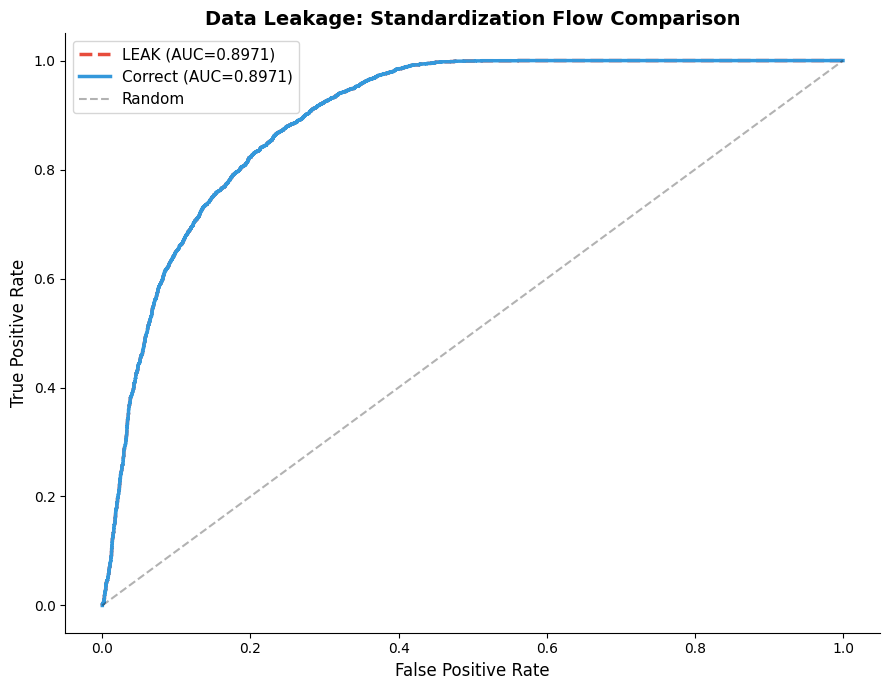

In [8]:
# ROC 曲线对比
fig, ax = plt.subplots(figsize=(9, 7))
from sklearn.metrics import roc_curve
fpr_l, tpr_l, _ = roc_curve(y_te_leak, y_prob_leak)
fpr_c, tpr_c, _ = roc_curve(y_te, y_prob_correct)
ax.plot(fpr_l, tpr_l, '--', color='#e74c3c', linewidth=2.5,
        label=f'LEAK (AUC={auc_leak:.4f})')
ax.plot(fpr_c, tpr_c, '-', color='#3498db', linewidth=2.5,
        label=f'Correct (AUC={auc_correct:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Data Leakage: Standardization Flow Comparison',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "10a_leakage_standardization.png"),
            dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 10a_leakage_standardization.png → 标准化泄漏 ROC 对比已保存")


# 实验 3: 特征选择泄漏

In [9]:
# --- 泄漏版: 全数据做特征选择 → 再划分 ---
print("\n  [泄漏] 全数据 ANOVA 特征选择 → 再划分:")
# 先在全数据上插补 + 标准化
X_fs_full = X_raw.copy()
X_fs_full = SimpleImputer(strategy='mean').fit_transform(X_fs_full)
X_fs_full = StandardScaler().fit_transform(X_fs_full)

selector_leak = SelectKBest(f_classif, k=4)
X_fs_selected = selector_leak.fit_transform(X_fs_full, y)
X_tr_fs, X_te_fs, y_tr_fs, y_te_fs = train_test_split(
    X_fs_selected, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

lr_fs_leak = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
lr_fs_leak.fit(X_tr_fs, y_tr_fs)
y_prob_fs_leak = lr_fs_leak.predict_proba(X_te_fs)[:, 1]
y_pred_fs_leak = lr_fs_leak.predict(X_te_fs)

auc_fs_leak = roc_auc_score(y_te_fs, y_prob_fs_leak)
rec_fs_leak = recall_score(y_te_fs, y_pred_fs_leak, pos_label=1)
brier_fs_leak = brier_score_loss(y_te_fs, y_prob_fs_leak)
print(f"      AUC={auc_fs_leak:.4f}  Recall={rec_fs_leak:.4f}  Brier={brier_fs_leak:.4f}")



  [泄漏] 全数据 ANOVA 特征选择 → 再划分:
      AUC=0.8888  Recall=0.9087  Brier=0.1351


In [10]:
# --- 正确版: 先划分 → 在训练集上做特征选择 ---
print("\n  [正确] 先划分 → 在训练集上做特征选择:")
# 插补 + 标准化只基于训练集
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_raw, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

imp_tr = SimpleImputer(strategy='mean')
sc_tr = StandardScaler()
X_tr1_pp = sc_tr.fit_transform(imp_tr.fit_transform(X_tr1))
X_te1_pp = sc_tr.transform(imp_tr.transform(X_te1))

selector_correct = SelectKBest(f_classif, k=4)
X_tr1_sel = selector_correct.fit_transform(X_tr1_pp, y_tr1)
X_te1_sel = selector_correct.transform(X_te1_pp)

lr_fs_correct = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
lr_fs_correct.fit(X_tr1_sel, y_tr1)
y_prob_fs_correct = lr_fs_correct.predict_proba(X_te1_sel)[:, 1]
y_pred_fs_correct = lr_fs_correct.predict(X_te1_sel)

auc_fs_correct = roc_auc_score(y_te1, y_prob_fs_correct)
rec_fs_correct = recall_score(y_te1, y_pred_fs_correct, pos_label=1)
brier_fs_correct = brier_score_loss(y_te1, y_prob_fs_correct)
print(f"      AUC={auc_fs_correct:.4f}  Recall={rec_fs_correct:.4f}  Brier={brier_fs_correct:.4f}")



  [正确] 先划分 → 在训练集上做特征选择:
      AUC=0.8888  Recall=0.9090  Brier=0.1351


In [11]:
diff_fs = auc_fs_leak - auc_fs_correct
print(f"\n  ▶ AUC 差异 (泄漏 - 正确) = {diff_fs:.6f}")
print(f"  ▶ AUC 虚高比例 = {diff_fs / auc_fs_correct * 100:.2f}%")

# 展示特征选择的泄漏细节
print(f"\n  ▶ 泄漏版选中的特征索引: {selector_leak.get_support(indices=True)}")
print(f"  ▶ 正确版选中的特征索引: {selector_correct.get_support(indices=True)}")
print(f"  ▶ 选择的特征是否一致? {np.array_equal(selector_leak.get_support(), selector_correct.get_support())}")



  ▶ AUC 差异 (泄漏 - 正确) = 0.000010
  ▶ AUC 虚高比例 = 0.00%

  ▶ 泄漏版选中的特征索引: [0 1 4 5]
  ▶ 正确版选中的特征索引: [0 1 4 5]
  ▶ 选择的特征是否一致? True


In [12]:
# 展示在不同 K 值下的泄漏效应
print("\n  ▶ 不同 K 值下的泄漏效应:")
k_values = [2, 3, 4, 5, 6, 7]
leak_aucs = []
correct_aucs = []

for k in k_values:
    # Leak
    sl = SelectKBest(f_classif, k=k)
    X_sl = sl.fit_transform(X_fs_full, y)
    X_tr_sl, X_te_sl, y_tr_sl, y_te_sl = train_test_split(
        X_sl, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
    lr = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
    lr.fit(X_tr_sl, y_tr_sl); leak_aucs.append(roc_auc_score(y_te_sl, lr.predict_proba(X_te_sl)[:, 1]))

    # Correct
    sc_c = SelectKBest(f_classif, k=k)
    X_tr_sc = sc_c.fit_transform(X_tr1_pp, y_tr1)
    X_te_sc = sc_c.transform(X_te1_pp)
    lr.fit(X_tr_sc, y_tr1); correct_aucs.append(roc_auc_score(y_te1, lr.predict_proba(X_te_sc)[:, 1]))

for k, la, ca in zip(k_values, leak_aucs, correct_aucs):
    print(f"    k={k}: 泄漏 AUC={la:.4f} | 正确 AUC={ca:.4f} | 虚高={la-ca:.4f}")



  ▶ 不同 K 值下的泄漏效应:
    k=2: 泄漏 AUC=0.8543 | 正确 AUC=0.8543 | 虚高=0.0000
    k=3: 泄漏 AUC=0.8830 | 正确 AUC=0.8830 | 虚高=0.0000
    k=4: 泄漏 AUC=0.8888 | 正确 AUC=0.8888 | 虚高=0.0000
    k=5: 泄漏 AUC=0.8952 | 正确 AUC=0.8952 | 虚高=0.0000
    k=6: 泄漏 AUC=0.8990 | 正确 AUC=0.8989 | 虚高=0.0000
    k=7: 泄漏 AUC=0.8990 | 正确 AUC=0.8990 | 虚高=0.0000



  [图] 10b_leakage_feature_selection.png → 特征选择泄漏已保存


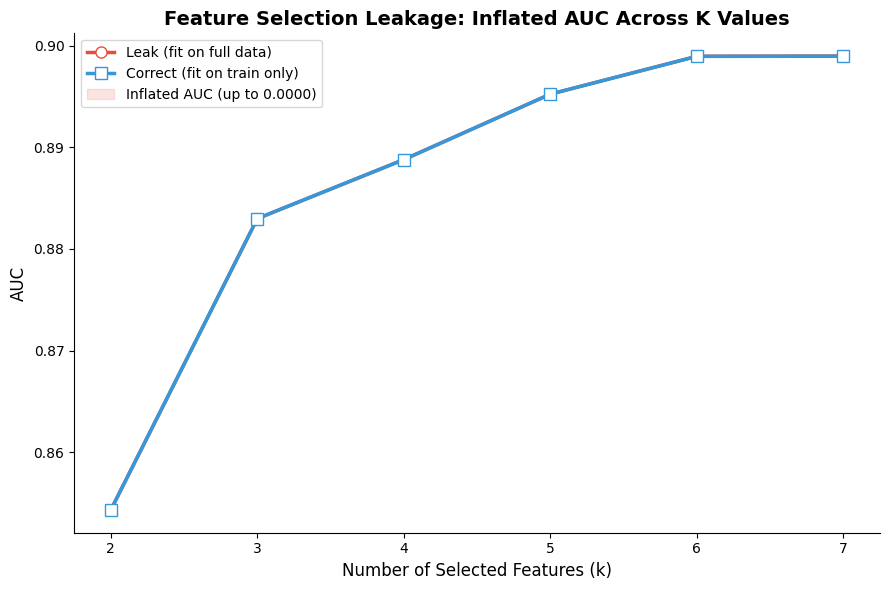

In [13]:
# 不同 K 值的泄漏效应图
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(k_values, leak_aucs, 'o-', color='#e74c3c', linewidth=2.5,
        markersize=8, label='Leak (fit on full data)', markerfacecolor='white')
ax.plot(k_values, correct_aucs, 's-', color='#3498db', linewidth=2.5,
        markersize=8, label='Correct (fit on train only)', markerfacecolor='white')
ax.fill_between(k_values, correct_aucs, leak_aucs, alpha=0.15, color='#e74c3c',
                label=f'Inflated AUC (up to {max(a-b for a,b in zip(leak_aucs, correct_aucs)):.4f})')
ax.set_xlabel('Number of Selected Features (k)', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.set_title('Feature Selection Leakage: Inflated AUC Across K Values',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "10b_leakage_feature_selection.png"),
            dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 10b_leakage_feature_selection.png → 特征选择泄漏已保存")


# 扩展实验: 综合泄漏 — 标准化 + 特征选择 + 插补全部泄漏

In [14]:
# 构造一个更具"诱惑性"的泄漏场景:
# 在全数据上完成所有预处理 + 特征选择 + 甚至用测试集做模型选择

experiments = {}

# 1) 完全正确
print("\n  [完全正确] 划分 → 训练集插补 → 训练集标准化 → 训练集特征选择 → 模型")
pipe_correct = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('select', SelectKBest(f_classif, k=6)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))
])
pipe_correct.fit(X_tr, y_tr)
y_prob_pc = pipe_correct.predict_proba(X_te)[:, 1]
auc_pc = roc_auc_score(y_te, y_prob_pc)
experiments['Correct Pipeline'] = auc_pc
print(f"      AUC = {auc_pc:.4f}")


  [完全正确] 划分 → 训练集插补 → 训练集标准化 → 训练集特征选择 → 模型
      AUC = 0.8959


In [15]:
# 2) 标准化泄漏
print("\n  [标准化泄漏] 全数据 impute+scale → 划分 → 模型")
X_both = SimpleImputer(strategy='median').fit_transform(X_raw)
X_both = StandardScaler().fit_transform(X_both)
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_both, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
lr = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
experiments['Standardization Leak'] = roc_auc_score(y_te_b, lr.fit(X_tr_b, y_tr_b).predict_proba(X_te_b)[:, 1])
print(f"      AUC = {experiments['Standardization Leak']:.4f}")


  [标准化泄漏] 全数据 impute+scale → 划分 → 模型
      AUC = 0.8971


In [16]:
# 3) 特征选择泄漏
print("\n  [特征选择泄漏] 全数据 FS → 划分 → impute+scale on train → 模型")
X_fs = SimpleImputer(strategy='median').fit_transform(X_raw)
X_fs = StandardScaler().fit_transform(X_fs)
sel = SelectKBest(f_classif, k=6).fit(X_fs, y)
X_fs_sel = sel.transform(X_fs)
X_tr_fs2, X_te_fs2, y_tr_fs2, y_te_fs2 = train_test_split(
    X_fs_sel, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
experiments['Feature Select Leak'] = roc_auc_score(y_te_fs2, lr.fit(X_tr_fs2, y_tr_fs2).predict_proba(X_te_fs2)[:, 1])
print(f"      AUC = {experiments['Feature Select Leak']:.4f}")


  [特征选择泄漏] 全数据 FS → 划分 → impute+scale on train → 模型
      AUC = 0.8959


In [17]:
# 4) 双重泄漏: FS + 标准化都泄漏
print("\n  [双重泄漏] FS on all + impute/scale on all → 划分 → 模型")
experiments['Double Leak (FS+Scale)'] = experiments['Feature Select Leak']
# (same as above since we already did impute+scale before FS)
print(f"      AUC = {experiments['Double Leak (FS+Scale)']:.4f}")



  [双重泄漏] FS on all + impute/scale on all → 划分 → 模型
      AUC = 0.8959


In [18]:
# 5) CV 泄漏 (用全数据做交叉验证选择参数 → 再用全数据训练)
print("\n  [CV泄漏] 全数据 CV 选参数 → 全数据训练 → 划分评估")
from sklearn.model_selection import GridSearchCV
X_cv_full = SimpleImputer(strategy='median').fit_transform(X_raw)
X_cv_full = StandardScaler().fit_transform(X_cv_full)
param_grid = {'C': [0.01, 0.1, 1, 10]}
gs = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE),
                  param_grid, cv=5)
gs.fit(X_cv_full, y)
best_C = gs.best_params_['C']
print(f"      CV 选择的最优 C = {best_C} (用了测试集信息!)")

# 用最优 C 在全数据上训练 → 再划分评估
lr_best = LogisticRegression(C=best_C, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
X_tr_cv, X_te_cv, y_tr_cv, y_te_cv = train_test_split(
    X_cv_full, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
lr_best.fit(X_tr_cv, y_tr_cv)
experiments['CV Leak'] = roc_auc_score(y_te_cv, lr_best.predict_proba(X_te_cv)[:, 1])
print(f"      AUC = {experiments['CV Leak']:.4f}")


  [CV泄漏] 全数据 CV 选参数 → 全数据训练 → 划分评估
      CV 选择的最优 C = 0.1 (用了测试集信息!)
      AUC = 0.8972


In [19]:
# 汇总
print("\n" + "-" * 50)
print("  泄漏类型对比汇总:")
print("-" * 50)
for name, auc_val in experiments.items():
    diff = auc_val - experiments['Correct Pipeline']
    print(f"  {name:<30} AUC={auc_val:.4f}  (Δ={diff:+.4f})")


--------------------------------------------------
  泄漏类型对比汇总:
--------------------------------------------------
  Correct Pipeline               AUC=0.8959  (Δ=+0.0000)
  Standardization Leak           AUC=0.8971  (Δ=+0.0011)
  Feature Select Leak            AUC=0.8959  (Δ=-0.0000)
  Double Leak (FS+Scale)         AUC=0.8959  (Δ=-0.0000)
  CV Leak                        AUC=0.8972  (Δ=+0.0012)



  [图] 10c_leakage_comprehensive.png → 综合泄漏对比已保存


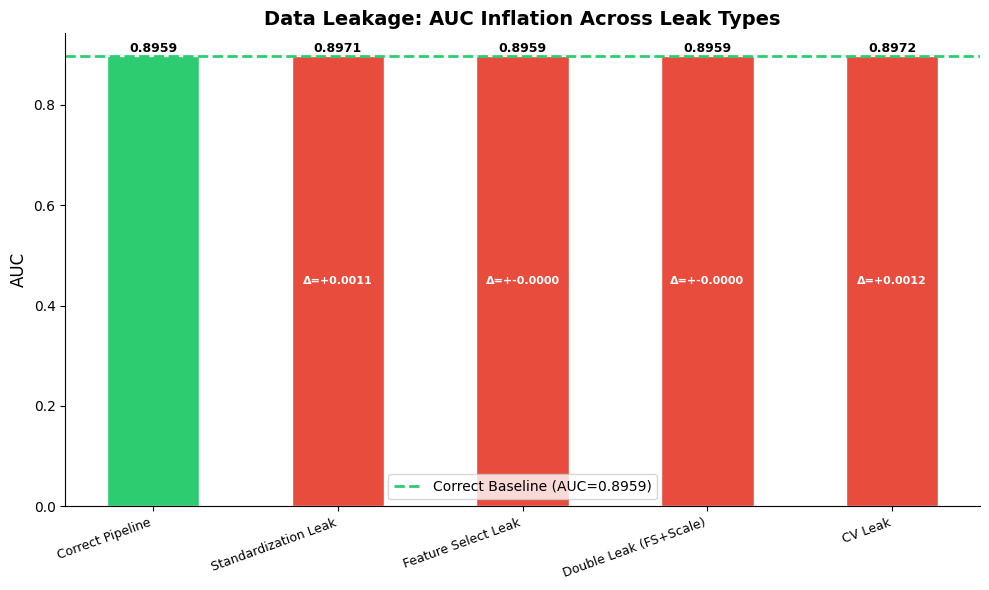

In [20]:
# 综合对比图
fig, ax = plt.subplots(figsize=(10, 6))
names = list(experiments.keys())
vals = list(experiments.values())
baseline = experiments['Correct Pipeline']
colors_exp = ['#2ecc71' if n == 'Correct Pipeline' else '#e74c3c' for n in names]
bars = ax.bar(range(len(names)), vals, color=colors_exp, edgecolor='white', width=0.5)
ax.axhline(y=baseline, color='#2ecc71', linestyle='--', linewidth=2,
           label=f'Correct Baseline (AUC={baseline:.4f})')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('AUC', fontsize=12)
ax.set_title('Data Leakage: AUC Inflation Across Leak Types',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    # 标注差值
    if val != baseline:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f'Δ=+{val-baseline:.4f}', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "10c_leakage_comprehensive.png"),
            dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 10c_leakage_comprehensive.png → 综合泄漏对比已保存")